# Objectives
Explore the distribution of car prices and identify outliers.

Visualize the relationship between car body types and prices.

Analyze the distribution of fuel types and transmissions.

Build predictive models to estimate car prices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

In [2]:
data=pd.read_csv('finaldata.csv')
data.head()

,Body,Transmission,Fuel,Brand,Model,Price,Color,Length,Width,Height,Wheel Base,Gear Box,Seats,Cargo Volume,Max Torque At
0,hatchback,manual,cng,maruti,maruti wagon r,370000,silver,3599.0,1495.0,1700.0,2400.0,5 speed,5.0,180.0,3500.0
1,hatchback,manual,cng,maruti,maruti celerio,365000,grey,3600.0,1600.0,1560.0,2425.0,5 speed,5.0,235.0,3500.0
2,sedan,manual,cng,honda,honda amaze,421000,silver,3990.0,1680.0,1505.0,2405.0,5 speed,5.0,400.0,4500.0
3,hatchback,manual,cng,maruti,maruti wagon r,240000,silver,3595.0,1475.0,1700.0,2400.0,5 speed,5.0,400.0,3500.0
4,muv,manual,cng,maruti,maruti ertiga,1175000,white,4395.0,1735.0,1690.0,2740.0,5 speed,7.0,400.0,4200.0


In [3]:
data.shape

(34104, 15)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34104 entries, 0 to 34103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Body           34104 non-null  object 
 1   Transmission   34104 non-null  object 
 2   Fuel           34104 non-null  object 
 3   Brand          34104 non-null  object 
 4   Model          34104 non-null  object 
 5   Price          34104 non-null  int64  
 6   Color          34104 non-null  object 
 7   Length         34104 non-null  float64
 8   Width          34104 non-null  float64
 9   Height         34104 non-null  float64
 10  Wheel Base     34104 non-null  float64
 11  Gear Box       34104 non-null  object 
 12  Seats          34104 non-null  float64
 13  Cargo Volume   34104 non-null  float64
 14  Max Torque At  34104 non-null  float64
dtypes: float64(7), int64(1), object(7)
memory usage: 3.9+ MB


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,34104.0,819363.900627,3.195303e+06,11963.0,319000.0,535000.0,890000.0,550000555.0
Length,34104.0,4120.563893,4.036742e+02,2752.0,3795.0,3995.0,4440.0,5982.0
Width,34104.0,1727.399982,1.303943e+02,1312.0,1680.0,1722.0,1790.0,2236.0
Height,34104.0,1578.591221,1.162622e+02,1165.0,1495.0,1530.0,1643.0,2075.0
Wheel Base,34104.0,2549.004340,1.579668e+02,1840.0,2425.0,2520.0,2650.0,3772.0
Seats,34104.0,5.243696,7.358842e-01,0.0,5.0,5.0,5.0,14.0
Cargo Volume,34104.0,360.991262,1.317169e+02,20.0,256.0,350.0,465.0,2055.0
Max Torque At,34104.0,3176.838098,1.027281e+03,160.0,2125.0,3400.0,4000.0,21800.0


In [6]:
data.isnull().sum()

Body             0
Transmission     0
Fuel             0
Brand            0
Model            0
Price            0
Color            0
Length           0
Width            0
Height           0
Wheel Base       0
Gear Box         0
Seats            0
Cargo Volume     0
Max Torque At    0
dtype: int64

In [7]:
data.nunique()

Body               11
Transmission        2
Fuel                5
Brand              46
Model             382
Price            6865
Color             747
Length            411
Width             276
Height            300
Wheel Base        219
Gear Box           11
Seats              11
Cargo Volume      203
Max Torque At     111
dtype: int64

# Renaming Some Values in 'Body' and 'Fuel' Columns

In [8]:
# Find the unique values of Body and Fuel
print("Unique values of Body are:\n", data['Body'].unique())
print("Unique values of Body Fuel:\n", data['Fuel'].unique())


Unique values of Body are:
 ['hatchback' 'sedan' 'muv' 'minivans' 'pickup trucks' 'suv'
 'luxury vehicles' 'convertibles' 'coupe' 'wagon' 'hybrids']
Unique values of Body Fuel:
 ['cng' 'lpg' 'electric' 'diesel' 'petrol']


In [9]:
# Title the values in specific columns
columns_to_title = ['Body', 'Transmission', 'Fuel', 'Brand', 'Model', 'Color']

for column in columns_to_title:
    data[column] = data[column].str.title()

# Define a function to selectively capitalize values
def capitalize_column(value):
    # List of values to be capitalized
    capitalize_values = ['cng', 'lpg', 'muv', 'suv']

    # Check if the value is in the list, and capitalize if true
    if value.lower() in capitalize_values:
        return value.upper()
    else:
        return value
# Apply the function to the 'Body' & 'Fuel' column
data['Body'] = data['Body'].apply(capitalize_column)
data['Fuel'] = data['Fuel'].apply(capitalize_column)
data.head()

,Body,Transmission,Fuel,Brand,Model,Price,Color,Length,Width,Height,Wheel Base,Gear Box,Seats,Cargo Volume,Max Torque At
0,Hatchback,Manual,CNG,Maruti,Maruti Wagon R,370000,Silver,3599.0,1495.0,1700.0,2400.0,5 speed,5.0,180.0,3500.0
1,Hatchback,Manual,CNG,Maruti,Maruti Celerio,365000,Grey,3600.0,1600.0,1560.0,2425.0,5 speed,5.0,235.0,3500.0
2,Sedan,Manual,CNG,Honda,Honda Amaze,421000,Silver,3990.0,1680.0,1505.0,2405.0,5 speed,5.0,400.0,4500.0
3,Hatchback,Manual,CNG,Maruti,Maruti Wagon R,240000,Silver,3595.0,1475.0,1700.0,2400.0,5 speed,5.0,400.0,3500.0
4,MUV,Manual,CNG,Maruti,Maruti Ertiga,1175000,White,4395.0,1735.0,1690.0,2740.0,5 speed,7.0,400.0,4200.0


# EDA

## How is the distribution of car prices?

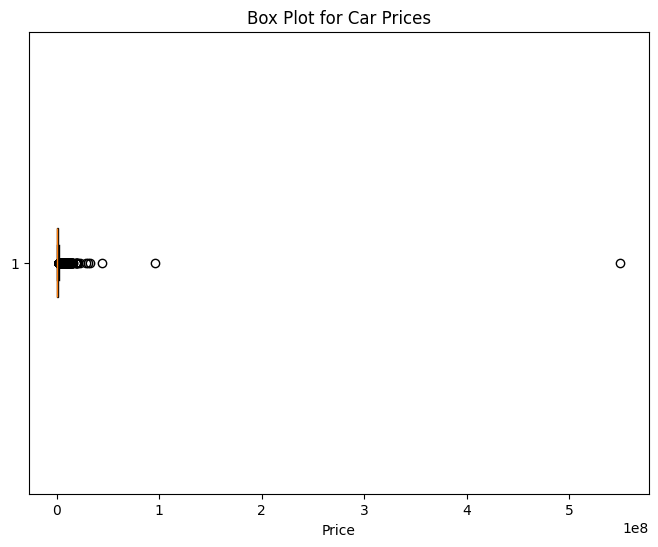

In [10]:
# Visualize the distribution using a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(data['Price'], vert=False, patch_artist=True)
plt.title('Box Plot for Car Prices')
plt.xlabel('Price')
plt.show()

## Get number of outliners

In [11]:
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
outliers = (data['Price'] < lower_bound) | (data['Price'] > upper_bound)
num_outliers = outliers.sum()
print(f"Number of outliers: {num_outliers}")

Number of outliers: 2834


remove outliers

In [12]:
data=data[~outliers]

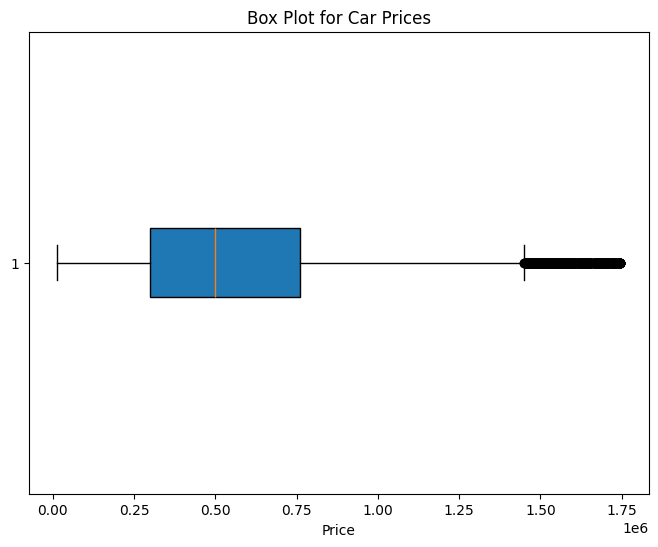

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot(data['Price'], vert=False, patch_artist=True)
plt.title('Box Plot for Car Prices')
plt.xlabel('Price')
plt.show()

## How is the distribution of car prices after removing the outliers?

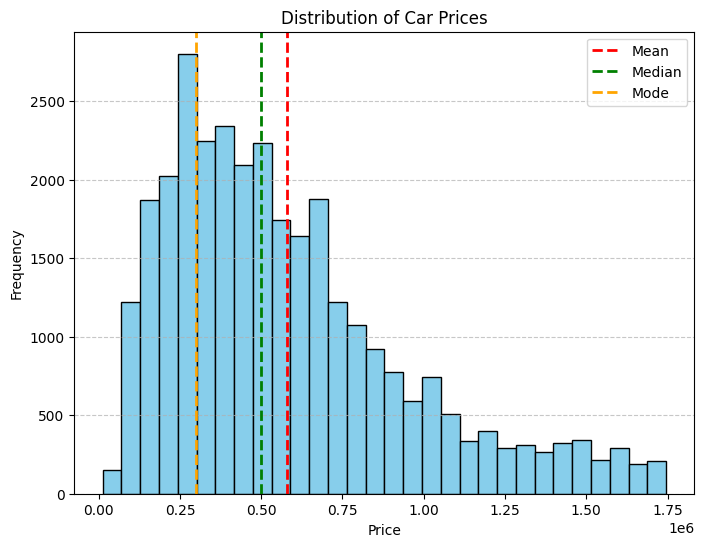

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(data['Price'], bins=30, color='skyblue', edgecolor='black')

# Add lines for mean, median, mode
plt.axvline(data['Price'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(data['Price'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.axvline(data['Price'].mode().iloc[0], color='orange', linestyle='dashed', linewidth=2, label='Mode')

plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## The total sales values vary by car body type?

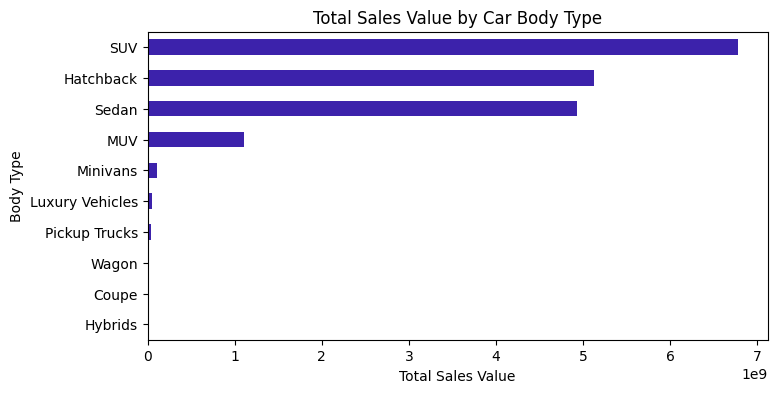

In [15]:
plt.figure(figsize=(8, 4))
body_sales = data.groupby('Body')['Price'].sum()
body_sales = body_sales.sort_values(ascending=True)
body_sales.plot(kind='barh', color='#3c22ab')
plt.title('Total Sales Value by Car Body Type')
plt.xlabel('Total Sales Value')
plt.ylabel('Body Type')
plt.show()

## What are the top  brands by average car price?

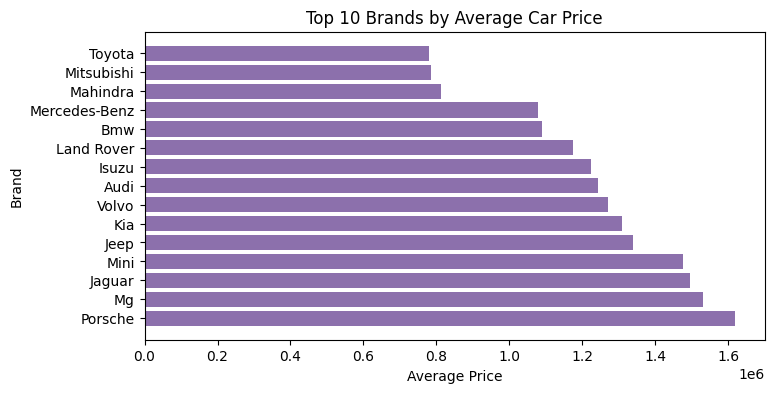

In [16]:
plt.figure(figsize=(8, 4))
brand_avg_price = data.groupby('Brand')['Price'].mean()
top_brands = brand_avg_price.sort_values(ascending=False).head(15)
plt.barh(top_brands.index, top_brands, color='#8c70ac')
plt.title('Top 10 Brands by Average Car Price')
plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.show()

## What is the distribution of car transmissions in the dataset

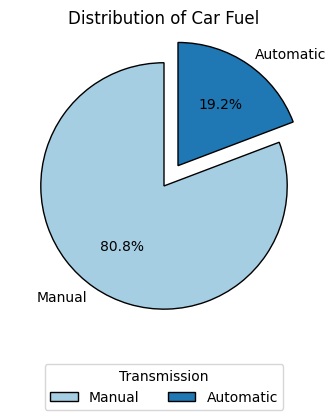

In [17]:
plt.figure(figsize=(4, 4))
color_distribution = data['Transmission'].value_counts()
plt.pie(color_distribution, labels=color_distribution.index, autopct='%1.1f%%',
        explode=[0,0.2] , startangle=90, wedgeprops={'edgecolor':'k'}, colors=plt.cm.Paired.colors)
plt.title('Distribution of Car Fuel')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), title='Transmission', ncol=len(color_distribution))
plt.show()

# What is the average cargo volume by car body type

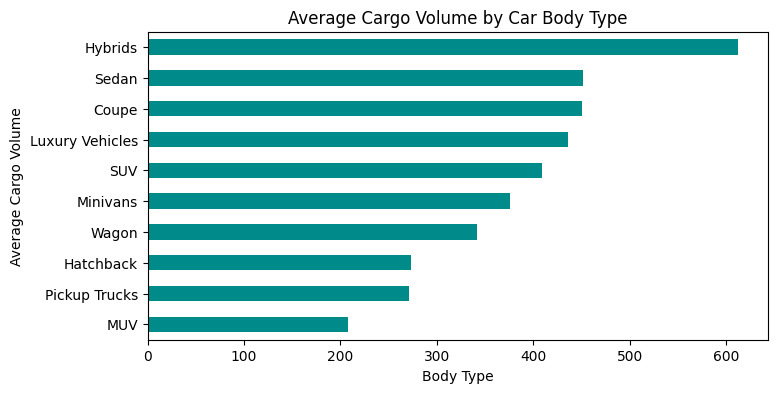

In [18]:
plt.figure(figsize=(8, 4))
body_avg_cargo = data.groupby('Body')['Cargo Volume'].mean()
body_avg_cargo = body_avg_cargo.sort_values(ascending=True)
body_avg_cargo.plot(kind='barh', color='#008b8b')
plt.title('Average Cargo Volume by Car Body Type')
plt.xlabel('Body Type')
plt.ylabel('Average Cargo Volume')
plt.xticks(rotation=0)
plt.show()

# correlation

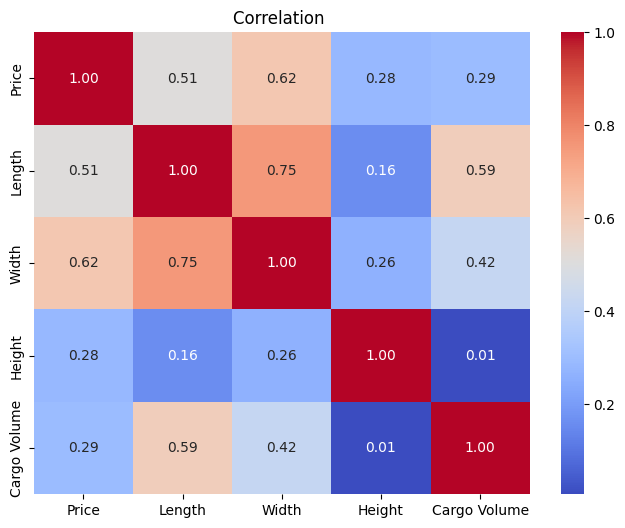

In [19]:
plt.figure(figsize=(8, 6))
correlation_matrix = data[['Price', 'Length', 'Width', 'Height', 'Cargo Volume']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation ')
plt.show()

## Data Preprocessing

In [20]:
# Convert 'Seats' column to integer type
data['Seats'] = data['Seats'].astype(int)

In [21]:
# Select the suitable features for the model
X=data.drop(['Body','Brand','Model', 'Color', 'Price'], axis=1)
y = data['Price']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f"\nTraining set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (28143, 10), Test set: (3127, 10)


In [22]:
# Columns to be label encoded
columns_to_label_encode = ['Transmission', 'Fuel', 'Gear Box']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Create a dictionary to store the mappings
encoding_mappings = {}

# Apply label encoding to the selected columns for both training and testing sets
for column in columns_to_label_encode:
    # Fit on the combined set to ensure consistent encoding across train and test
    label_encoder.fit(pd.concat([X_train[column], X_test[column]], axis=0))

    # Transform the values in both training and testing sets
    X_train[column + '_encoded'] = label_encoder.transform(X_train[column])
    X_test[column + '_encoded'] = label_encoder.transform(X_test[column])
     # Store the mapping in the dictionary
    encoding_mappings[column] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    # Drop the original categorical columns
X_train = X_train.drop(columns=columns_to_label_encode)
X_test = X_test.drop(columns=columns_to_label_encode)


# Training and Evaluating Different Models

In [23]:
# List of models to try
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor()),
    ('Random Forest', RandomForestRegressor()),
    ('Gradient Boosting', GradientBoostingRegressor()),
    ('K-Nearest Neighbors', KNeighborsRegressor())
]

# Train and evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'{name}: Mean Squared Error = {round(mse,3)}, R-squared = {round(r2, 3)}')

Linear Regression: Mean Squared Error = 66496697168.382, R-squared = 0.509
Ridge Regression: Mean Squared Error = 66496580936.008, R-squared = 0.509
Decision Tree: Mean Squared Error = 21197396904.087, R-squared = 0.844
Random Forest: Mean Squared Error = 19401178411.755, R-squared = 0.857
Gradient Boosting: Mean Squared Error = 33801705321.388, R-squared = 0.751
K-Nearest Neighbors: Mean Squared Error = 25543071831.426, R-squared = 0.812


## Explanation
Linear Regression:     MSE = 6.65×10¹⁰,  R² = 0.509  
Ridge Regression:      MSE = 6.65×10¹⁰,  R² = 0.509  
Decision Tree:         MSE = 2.13×10¹⁰,  R² = 0.843  
Random Forest:         MSE = 1.94×10¹⁰,  R² = 0.857  
Gradient Boosting:     MSE = 3.38×10¹⁰,  R² = 0.751  
K‑Nearest Neighbors:   MSE = 2.55×10¹⁰,  R² = 0.812

** Mean Squared Error (MSE)

Interpretation: average squared distance between true prices (𝑦𝑖) and predictions (𝑦^𝑖).

Goal: lower is better.

**2. R‑squared (R²)
Interpretation: fraction of variance in the target explained by the model.

Range: can be negative (worse than predicting the mean) up to 1 (perfect fit).

Goal: higher is better.



### Based on both metrics, Random Forest is the best off‑the‑shelf choice.

## Hyperparameter Tuning for the best model (Random Forest)

In [24]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_model_tuned = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(rf_model_tuned, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_

# Retrain the model with the best parameters
rf_model_best = RandomForestRegressor(**best_params, random_state=42)
rf_model_best.fit(X_train, y_train)

# Predict using the updated features
y_predd= rf_model_best.predict(X_test)


### The optimal hyperparameters for the Random Forest model after tuning

In [25]:
mse_best = mean_squared_error(y_test, y_predd)
r2_best = r2_score(y_test, y_predd)

print(f'Best Parameters: {best_params}')
print(f'Mean Squared Error (Tuned Random Forest): {round(mse_best, 3)}')
print(f'R-squared (Tuned Random Forest): {round(r2_best, 3)}')

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Mean Squared Error (Tuned Random Forest): 19220287867.378
R-squared (Tuned Random Forest): 0.858


How well do the predicted prices align with the actual prices?

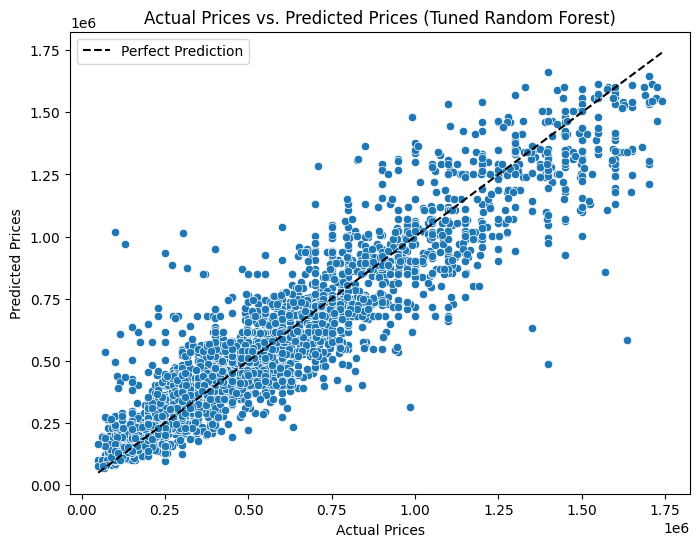

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_predd)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='black', label='Perfect Prediction')
plt.title('Actual Prices vs. Predicted Prices (Tuned Random Forest)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

What is the pattern of residuals in the model predictions?

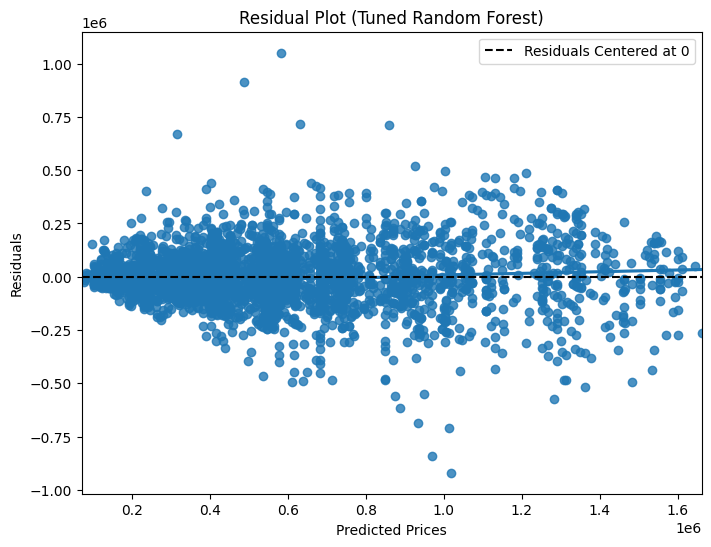

In [27]:
plt.figure(figsize=(8, 6))
sns.residplot(x=y_predd, y=y_test, lowess=True)
plt.axhline(y=0, color='black', linestyle='--', label='Residuals Centered at 0')
plt.title('Residual Plot (Tuned Random Forest)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.legend()
plt.show()

Which features have the most significant impact on predicting car prices in the tuned Random Forest model?

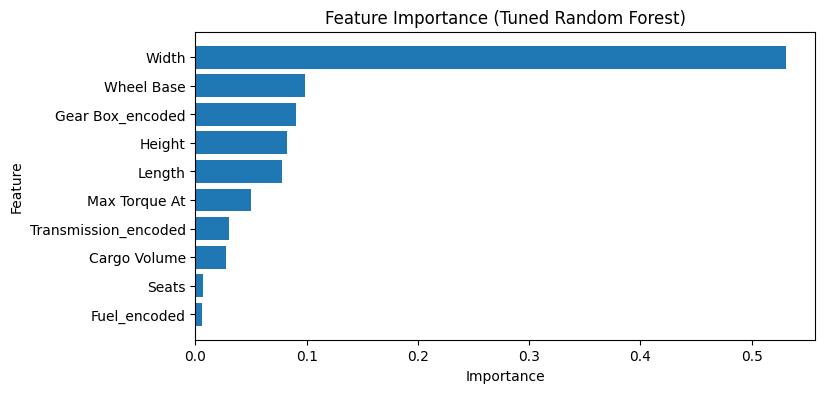

In [28]:
# Visualize the features of the tuned random forest
feature_importances = rf_model_best.feature_importances_
feature_names = X_train.columns

# Sort features by importance
sorted_idx = feature_importances.argsort()

plt.figure(figsize=(8, 4))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.title('Feature Importance (Tuned Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Save the trained model using joblib

In [29]:
import joblib


joblib.dump(rf_model_best, 'model.pkl')

['model.pkl']

In [30]:
# Load the pre-trained model
rf_model_best = joblib.load('model.pkl')

# Generating New Data and Predicting the Prices

In [31]:
new_data = {
    'Length': [3765.0, 3840.0, 3675.0, 3445.0, 3940.0],
    'Width': [1660.0, 1735.0, 1475.0, 1515.0, 1710.0],
    'Height': [1520.0, 1530.0, 1825.0, 1475.0, 1505.0],
    'Wheel Base': [2420.0, 2650.0, 2330.0, 2400.0, 3000.0],
    'Seats': [2, 7, 5, 11, 4],
    'Cargo Volume': [350.0, 150.0, 200.0, 420.0, 170.0],
    'Max Torque At': [2560.0, 2004.0, 2100.0, 3500.0, 2950.0],
    'Transmission_encoded': [1, 0, 0, 1, 1],
    'Fuel_encoded': [4, 1, 3, 5, 2],
    'Gear Box_encoded': [7, 2, 5, 1, 3],
}

# Create a DataFrame with the synthetic data
new_df = pd.DataFrame(new_data)
# Predict prices for the new data
new_predictions = rf_model_best.predict(new_df)
new_df['Predicted Price'] = new_predictions
new_df

,Length,Width,Height,Wheel Base,Seats,Cargo Volume,Max Torque At,Transmission_encoded,Fuel_encoded,Gear Box_encoded,Predicted Price
0,3765.0,1660.0,1520.0,2420.0,2,350.0,2560.0,1,4,7,374725.007461
1,3840.0,1735.0,1530.0,2650.0,7,150.0,2004.0,0,1,2,683222.090774
2,3675.0,1475.0,1825.0,2330.0,5,200.0,2100.0,0,3,5,439492.817824
3,3445.0,1515.0,1475.0,2400.0,11,420.0,3500.0,1,5,1,192910.109479
4,3940.0,1710.0,1505.0,3000.0,4,170.0,2950.0,1,2,3,479846.240640
